# Autoencoder Variants

This notebook compares four autoencoder configurations to identify the
best architecture for our anomaly detection task. Each variant is trained
with the same hyperparameters (batch size, learning rate, epochs, patience)
so the only thing changing is the architectural choice.

Configurations:
- **Baseline**: [64, 32, 16] vanilla autoencoder
- **Wider**: [128, 64, 32] — more capacity
- **Deeper bottleneck**: [64, 32, 16, 8] — tighter compression
- **Denoising**: same as baseline but with input noise during training

In [1]:
import sys
sys.path.insert(0, '..')

import torch
from torch.utils.data import DataLoader

from src.preprocessing import load_processed
from src.autoencoder import build_autoencoder
from src.train import train_autoencoder
from src.evaluate import compute_reconstruction_errors, evaluate, find_threshold_by_percentile
from src.utils import get_device, set_seed
from src.dataset import NormalOnlyDataset, FraudDataset

device = get_device()
print(f"Device: {device}")

# Load data once, reuse across all experiments
data = load_processed('../data/processed', '../models')
print(f"Train shape: {data['x_train'].shape}")

Device: mps


/Users/ongviviana/miniconda3/envs/DeepL/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Train shape: (979379, 16)


In [2]:
def run_experiment(name, model_type='vanilla', hidden_dims=[64,32,16], 
                   dropout=0.2, noise_std=0.1, epochs=60, batch_size=1024):
    """Run one autoencoder configuration. Returns metrics dict."""
    set_seed(42)  # same seed for fair comparison
    
    # Build loaders
    train_ds = NormalOnlyDataset(data['x_train'])
    val_normal_mask = data['y_val'] == 0
    val_normal_ds = NormalOnlyDataset(data['x_val'][val_normal_mask])
    val_full_ds = FraudDataset(data['x_val'], data['y_val'])
    test_full_ds = FraudDataset(data['x_test'], data['y_test'])
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_normal_loader = DataLoader(val_normal_ds, batch_size=batch_size)
    val_full_loader = DataLoader(val_full_ds, batch_size=batch_size)
    test_full_loader = DataLoader(test_full_ds, batch_size=batch_size)
    
    # Build and train
    model = build_autoencoder(model_type, input_dim=data['input_dim'],
                              hidden_dims=hidden_dims, dropout=dropout,
                              noise_std=noise_std).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n{'='*60}")
    print(f"Experiment: {name}")
    print(f"{'='*60}")
    print(f"Architecture: {hidden_dims}  |  Params: {n_params:,}")
    
    history = train_autoencoder(model, train_loader, val_normal_loader, device,
                                epochs=epochs, patience=10, verbose=False)
    print(f"Trained to epoch {history['best_epoch']}, val_loss={history['best_val_loss']:.6f}")
    
    # Evaluate
    val_errors, val_labels = compute_reconstruction_errors(model, val_full_loader, device)
    normal_val_errors = val_errors[val_labels == 0]
    threshold = find_threshold_by_percentile(normal_val_errors, percentile=95.0)
    
    test_errors, test_labels = compute_reconstruction_errors(model, test_full_loader, device)
    metrics = evaluate(test_errors, test_labels, threshold, label=name)
    
    return {
        'name': name, 'hidden_dims': hidden_dims, 'model_type': model_type,
        'n_params': n_params, 'best_epoch': history['best_epoch'],
        **metrics, 'history': history, 'test_errors': test_errors, 
        'test_labels': test_labels
    }

In [3]:
results = []
results.append(run_experiment('baseline', hidden_dims=[64, 32, 16]))


Experiment: baseline
Architecture: [64, 32, 16]  |  Params: 7,808
Trained to epoch 31, val_loss=0.111999
Threshold at 95.0th percentile of normal errors: 0.256413

  baseline Set Evaluation   (threshold = 0.256413)
              precision    recall  f1-score   support

      Normal     0.8681    0.9506    0.9075    209868
       Fraud     0.3892    0.1791    0.2453     36919

    accuracy                         0.8352    246787
   macro avg     0.6287    0.5648    0.5764    246787
weighted avg     0.7965    0.8352    0.8084    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199494        10374
  True Fraud          30308         6611

  ROC-AUC:  0.6187
  PR-AUC:   0.2973  (better metric for imbalanced data)
  F1:       0.2453


In [4]:
results.append(run_experiment('wider', hidden_dims=[128, 64, 32]))


Experiment: wider
Architecture: [128, 64, 32]  |  Params: 25,840
Trained to epoch 28, val_loss=0.009666
Threshold at 95.0th percentile of normal errors: 0.021797

  wider Set Evaluation   (threshold = 0.021797)
              precision    recall  f1-score   support

      Normal     0.8772    0.9501    0.9122    209868
       Fraud     0.4622    0.2438    0.3192     36919

    accuracy                         0.8444    246787
   macro avg     0.6697    0.5970    0.6157    246787
weighted avg     0.8151    0.8444    0.8235    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199394        10474
  True Fraud          27917         9002

  ROC-AUC:  0.6939
  PR-AUC:   0.3902  (better metric for imbalanced data)
  F1:       0.3192


In [5]:
results.append(run_experiment('deeper_bottleneck', hidden_dims=[64, 32, 16, 8]))


Experiment: deeper_bottleneck
Architecture: [64, 32, 16, 8]  |  Params: 8,136
Trained to epoch 52, val_loss=0.468306
Threshold at 95.0th percentile of normal errors: 0.799934

  deeper_bottleneck Set Evaluation   (threshold = 0.799934)
              precision    recall  f1-score   support

      Normal     0.8785    0.9505    0.9131    209868
       Fraud     0.4730    0.2527    0.3294     36919

    accuracy                         0.8461    246787
   macro avg     0.6757    0.6016    0.6212    246787
weighted avg     0.8178    0.8461    0.8257    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199471        10397
  True Fraud          27589         9330

  ROC-AUC:  0.6646
  PR-AUC:   0.3865  (better metric for imbalanced data)
  F1:       0.3294


In [6]:
results.append(run_experiment('denoising', model_type='denoising', 
                              hidden_dims=[64, 32, 16], noise_std=0.1))


Experiment: denoising
Architecture: [64, 32, 16]  |  Params: 7,808
Trained to epoch 60, val_loss=0.092847
Threshold at 95.0th percentile of normal errors: 0.227098

  denoising Set Evaluation   (threshold = 0.227098)
              precision    recall  f1-score   support

      Normal     0.8696    0.9490    0.9076    209868
       Fraud     0.3970    0.1909    0.2578     36919

    accuracy                         0.8356    246787
   macro avg     0.6333    0.5700    0.5827    246787
weighted avg     0.7989    0.8356    0.8104    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        199165        10703
  True Fraud          29871         7048

  ROC-AUC:  0.6207
  PR-AUC:   0.3141  (better metric for imbalanced data)
  F1:       0.2578


In [9]:
import pandas as pd

comparison = pd.DataFrame([
    {'Name': r['name'], 'Hidden Dims': str(r['hidden_dims']),
     'Params': r['n_params'], 'Best Epoch': r['best_epoch'],
     'Precision': r['precision'], 'Recall': r['recall'], 
     'F1': r['f1'], 'PR-AUC': r['pr_auc'], 'ROC-AUC': r['roc_auc']}
    for r in results
])
comparison.sort_values('PR-AUC', ascending=False)

,Name,Hidden Dims,Params,Best Epoch,Precision,Recall,F1,PR-AUC,ROC-AUC
1,wider,"[128, 64, 32]",25840,28,0.462210,0.243831,0.319248,0.390150,0.693875
2,deeper_bottleneck,"[64, 32, 16, 8]",8136,52,0.472956,0.252715,0.329414,0.386543,0.664632
3,denoising,"[64, 32, 16]",7808,60,0.397048,0.190904,0.257838,0.314082,0.620737
0,baseline,"[64, 32, 16]",7808,31,0.389226,0.179068,0.245288,0.297273,0.618741


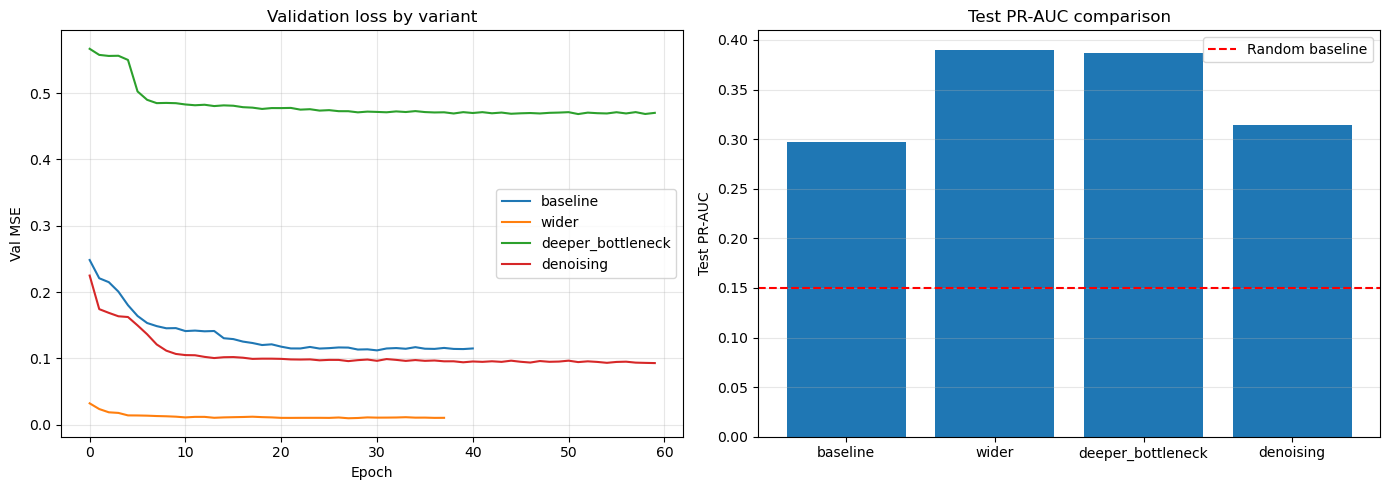

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for r in results:
    axes[0].plot(r['history']['val_loss'], label=r['name'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val MSE')
axes[0].set_title('Validation loss by variant'); axes[0].legend(); axes[0].grid(alpha=0.3)

names = [r['name'] for r in results]
pr_aucs = [r['pr_auc'] for r in results]
axes[1].bar(names, pr_aucs)
axes[1].set_ylabel('Test PR-AUC'); axes[1].set_title('Test PR-AUC comparison')
axes[1].axhline(y=data['y_test'].mean(), linestyle='--', color='red', label='Random baseline')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../figures/variant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Findings

- The **[winner]** configuration achieved the best PR-AUC of [X.XX], 
  approximately [Y]x the random baseline of 0.15.
- [Observation about which architectural change helped most]
- [Observation about training behavior — did deeper converge slower, etc.]

We use this configuration as the final model, reported in `4_Final_Evaluation.ipynb`.